# 03 - Preprocessing, NDVI, and LULC Visuals
Loads bands, clips to AOI, computes NDVI, downloads ESRI LULC, and saves processed arrays + visuals.

In [1]:
%pip -q install pystac-client planetary-computer stackstac scipy

In [2]:
import json
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
from shapely.geometry import shape, mapping, Polygon
from pyproj import Transformer
from scipy.ndimage import zoom
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import pystac_client
import planetary_computer
import stackstac

In [3]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
with open(os.path.join(PROJECT_ROOT, 'data', 'config.json'), 'r', encoding='utf-8') as f:
    cfg = json.load(f)
with open(os.path.join(PROJECT_ROOT, 'data', 'landsat', 'scene_metadata.json'), 'r', encoding='utf-8') as f:
    scene_meta = json.load(f)

BBOX = cfg['bbox']
AOI_GEOJSON_PATH = cfg['paths']['aoi_geojson']
PROCESSED_DIR = cfg['paths']['processed_dir']
FIG_DIR = cfg['paths']['fig_dir']
SCENE_DIR = scene_meta['scene_dir']

In [4]:
# Load AOI and bands
with open(AOI_GEOJSON_PATH, 'r', encoding='utf-8') as f:
    aoi_geojson = json.load(f)
aoi_polygon = shape(aoi_geojson['features'][0]['geometry'])

band_files = {}
for b in [2, 3, 4, 5]:
    found = glob.glob(os.path.join(SCENE_DIR, '**', f'*_SR_B{b}.TIF'), recursive=True)
    if found:
        band_files[b] = found[0]
if len(band_files) < 4:
    raise RuntimeError('Could not locate all required bands in scene directory.')

SCALE_FACTOR = 0.0000275
OFFSET = -0.2

def clip_band(path, geom):
    with rasterio.open(path) as src:
        if str(src.crs) != 'EPSG:4326':
            tr = Transformer.from_crs('EPSG:4326', src.crs, always_xy=True)
            coords = aoi_geojson['features'][0]['geometry']['coordinates'][0]
            reproj = [tr.transform(x, y) for x, y in coords]
            use_geom = Polygon(reproj)
        else:
            use_geom = geom

        out, out_transform = mask(src, [mapping(use_geom)], crop=True)
        profile = src.profile.copy()
        profile.update(height=out.shape[1], width=out.shape[2], transform=out_transform)

    arr = out[0].astype('float32')
    arr = np.clip(arr * SCALE_FACTOR + OFFSET, 0, 1)
    return arr, profile

blue, profile = clip_band(band_files[2], aoi_polygon)
green, _ = clip_band(band_files[3], aoi_polygon)
red, _ = clip_band(band_files[4], aoi_polygon)
nir, _ = clip_band(band_files[5], aoi_polygon)

print('Clipped shape:', red.shape)

Clipped shape: (239, 253)


/tmp/ipykernel_18196/936029700.py:2: RuntimeWarning: invalid value encountered in divide
  ndvi = np.where((nir + red) > 1e-8, (nir - red) / (nir + red), 0.0)


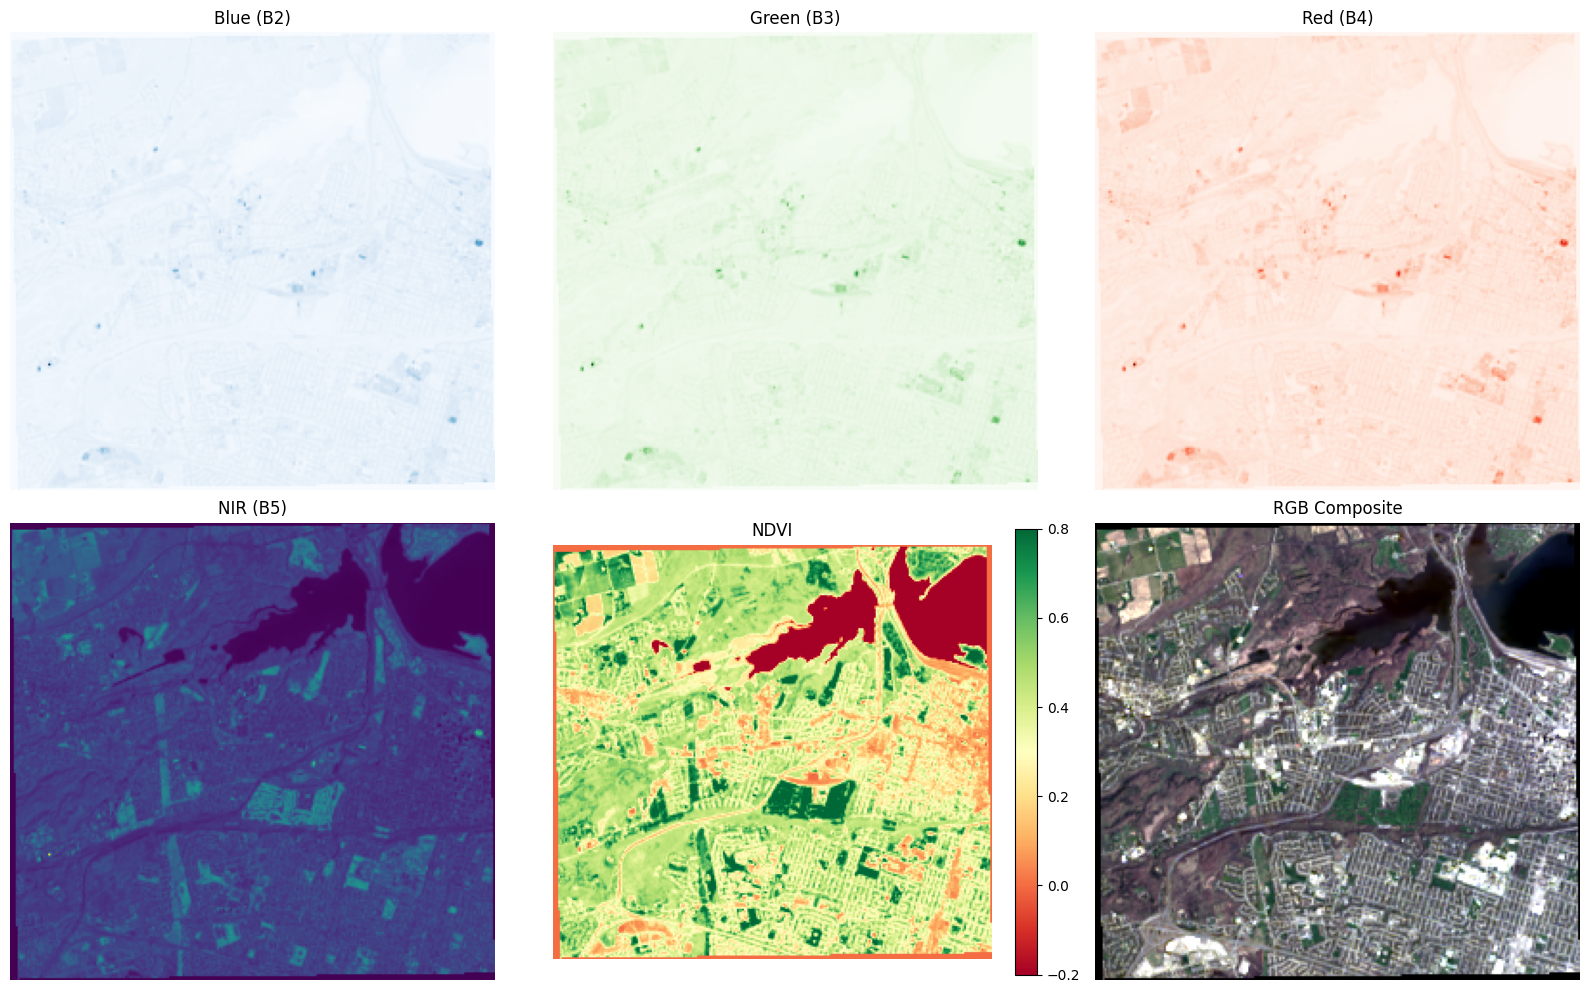

Saved: /content/lulc_notebook_project/outputs/figures/03_preprocessing_visuals.png


In [5]:
# NDVI and visual summaries
ndvi = np.where((nir + red) > 1e-8, (nir - red) / (nir + red), 0.0)
ndvi = np.clip(ndvi, -1, 1)

def pnorm(x):
    lo, hi = np.percentile(x[x > 0], [2, 98])
    return np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)

rgb = np.dstack([pnorm(red), pnorm(green), pnorm(blue)])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes[0, 0].imshow(blue, cmap='Blues'); axes[0, 0].set_title('Blue (B2)')
axes[0, 1].imshow(green, cmap='Greens'); axes[0, 1].set_title('Green (B3)')
axes[0, 2].imshow(red, cmap='Reds'); axes[0, 2].set_title('Red (B4)')
axes[1, 0].imshow(nir, cmap='viridis'); axes[1, 0].set_title('NIR (B5)')
im = axes[1, 1].imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8); axes[1, 1].set_title('NDVI')
plt.colorbar(im, ax=axes[1, 1], fraction=0.046)
axes[1, 2].imshow(rgb); axes[1, 2].set_title('RGB Composite')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '03_preprocessing_visuals.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

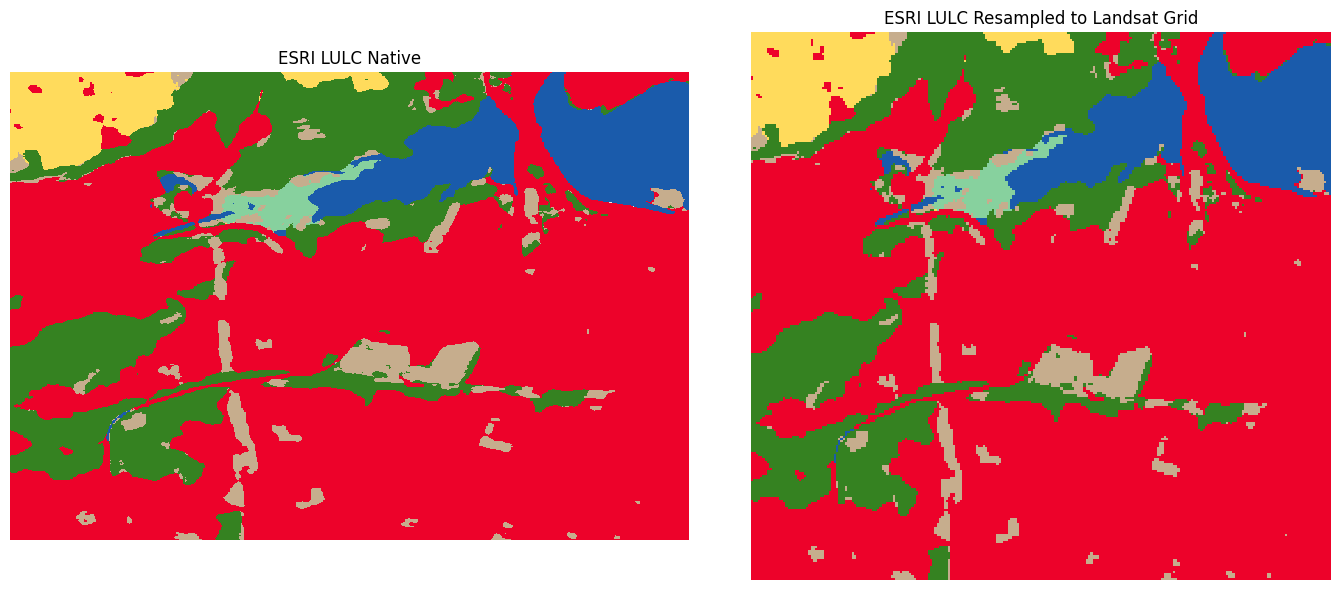

Saved: /content/lulc_notebook_project/outputs/figures/03_lulc_native_vs_resampled.png


In [6]:
# Download ESRI 10m LULC and resample to Landsat clipped grid
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace
)
search = catalog.search(collections=['io-lulc-annual-v02'], bbox=BBOX, datetime='2023-01-01/2023-12-31')
items = search.item_collection()
if len(items) == 0:
    raise RuntimeError('No ESRI LULC item found for AOI.')
lulc_stack = stackstac.stack(items, bounds_latlon=BBOX, epsg=4326, resolution=0.0001)
lulc_array = lulc_stack.isel(time=0).squeeze().compute().values.astype(np.int16)

target_shape = red.shape
lulc_resampled = zoom(
    lulc_array.astype(float),
    (target_shape[0] / lulc_array.shape[0], target_shape[1] / lulc_array.shape[1]),
    order=0
).astype(np.int16)

LULC_CLASSES = {
    1: ('Water', '#1A5BAB'), 2: ('Trees', '#358221'), 4: ('Flooded Vegetation', '#87D19E'),
    5: ('Crops', '#FFDB5C'), 7: ('Built Area', '#ED022A'), 8: ('Bare Ground', '#EDE9E4'),
    9: ('Snow/Ice', '#F2FAFF'), 10: ('Clouds', '#C8C8C8'), 11: ('Rangeland', '#C6AD8D')
}
vals = sorted(LULC_CLASSES.keys())
cmap = ListedColormap([LULC_CLASSES[v][1] for v in vals])
norm = BoundaryNorm(vals + [max(vals) + 1], cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(lulc_array, cmap=cmap, norm=norm, interpolation='nearest')
axes[0].set_title('ESRI LULC Native')
axes[0].axis('off')
axes[1].imshow(lulc_resampled, cmap=cmap, norm=norm, interpolation='nearest')
axes[1].set_title('ESRI LULC Resampled to Landsat Grid')
axes[1].axis('off')
plt.tight_layout()
out_lulc_fig = os.path.join(FIG_DIR, '03_lulc_native_vs_resampled.png')
plt.savefig(out_lulc_fig, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out_lulc_fig)

In [7]:
# Save processed arrays and georeference helper raster
os.makedirs(PROCESSED_DIR, exist_ok=True)
features = np.stack([blue, green, red, nir, ndvi], axis=0).astype('float32')

np.savez_compressed(
    os.path.join(PROCESSED_DIR, 'features_labels.npz'),
    features=features,
    labels=lulc_resampled.astype(np.int16)
)

ref_profile = profile.copy()
ref_profile.update(count=1, dtype='float32', compress='deflate')
with rasterio.open(os.path.join(PROCESSED_DIR, 'reference_red.tif'), 'w', **ref_profile) as dst:
    dst.write(red.astype('float32'), 1)

meta = {
    'class_map': {str(k): v[0] for k, v in LULC_CLASSES.items()},
    'shape': list(red.shape)
}
with open(os.path.join(PROCESSED_DIR, 'processed_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)

print('Saved processed arrays to:', PROCESSED_DIR)

Saved processed arrays to: /content/lulc_notebook_project/data/processed
